In [2]:
"Up and running"

'Up and running'

In [ ]:
# Built-in modules
import json
from collections import Counter

# Third-party modules
import umap
import numpy as np
import pandas as pd
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt

# Custom modules
from misc import paths
from misc import config
from misc.logger import logger
from entity.collection import ProteinCollection
from families.domain_architecture import DomainArchitecture
logger.info('Importing modules completed')

/home/asanchez/chonky/miniconda3/envs/pofft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2520094800.py INFO Importing modules completed


In [3]:
# Gather Protein objects
file_path = paths.COLLECTIONS / 'all.prot'
collection = ProteinCollection(
    file_path=file_path,
    datasets=['uniprot', 'taxon', 'esm2_embeddings', 'family'],
)
proteins = [protein for protein in collection]

Loading Protein collection from HDF5 file: 100%|██████████| 76083/76083 [22:09<00:00, 57.24it/s]  


In [4]:
# UMAP
x = [protein.esm2_embeddings[config.ESM2_MODEL] for protein in proteins]
X = np.stack(x)
reducer = umap.UMAP(n_components=2, random_state=42)
Z = reducer.fit_transform(X)

/home/asanchez/chonky/miniconda3/envs/pofft/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Plot bare UMAP

In [14]:
# Dataframe
df = pd.DataFrame({
    'UMAP1': Z[:, 0],
    'UMAP2': Z[:, 1],
    'Family': [
        DomainArchitecture(protein.family).as_pfam_names().prettify()
        for protein in proteins
    ],
    'Species': [
        protein.taxon 
        for protein in proteins
    ]
})


In [ ]:
# Interactive
fig = px.scatter(
    df, 
    x='UMAP1', y='UMAP2', 
    title='UMAP 2D',
    hover_data=['Family', 'Species']
    )
fig.update_traces(marker=dict(size=3))
fig.write_html("bare.html")

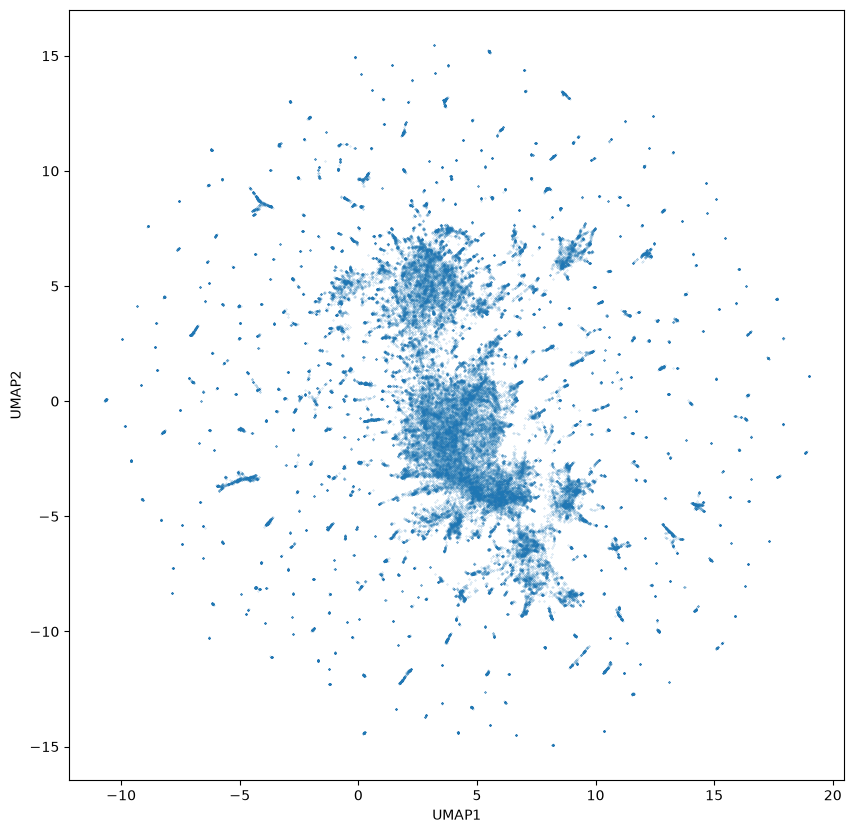

In [ ]:
# Static
fig, ax = plt.subplots(figsize=(10, 10))
fig = df.plot.scatter(x='UMAP1', y='UMAP2', ax=ax, alpha=0.5, s=0.05)

# Plot with species labels

In [16]:
# Find most common species
species = [protein.taxon for protein in proteins]
counter = Counter(species)
common_species = list(zip(*counter.most_common(6)))[0]
species = [
    protein.taxon if protein.taxon in common_species else 'Other'
    for protein in proteins
]
df['Common Species'] = species

In [18]:
# Interactive
fig = px.scatter(
    df, 
    x='UMAP1', y='UMAP2', 
    title='UMAP 2D',
    color='Common Species',
    hover_data=['Family', 'Species']
    )
fig.update_traces(marker=dict(size=3))
fig.write_html("species.html")

Text(0, 0.5, 'UMAP2')

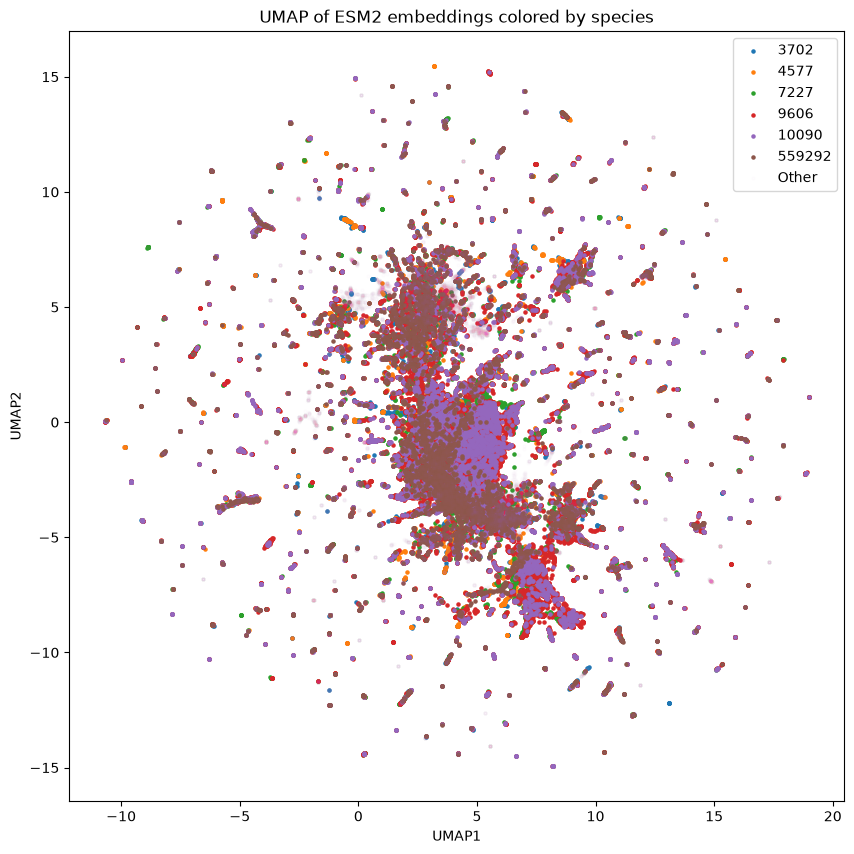

In [ ]:
# Static
df['Common Species'] = species
fig, ax = plt.subplots(figsize=(10, 10))
for species, group in df.groupby('Common Species'):
    ax.scatter(
        group['UMAP1'], 
        group['UMAP2'], 
        label=species, 
        alpha=0.01 if species == 'Other' else 1.0, 
        s=5
    )
ax.legend()
plt.title('UMAP of ESM2 embeddings colored by species')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

# Plot with families label

In [19]:
# Load representatives
with open(paths.FAMILIES / 'accession2representative.json', 'r') as f:
    accession2representative = json.load(f)

# Prettify them
archs = []
for protein in tqdm(proteins):
    representative = accession2representative[protein.uniprot]
    architecture = DomainArchitecture(representative)
    architecture = architecture.as_pfam_names().prettify()
    archs.append(architecture)

# Find most common
counter = Counter(archs)
common_families = list(zip(*counter.most_common(10)))[0]
families = [
    arch if arch in common_families else 'Other'
    for arch in archs
]
df['Common Families'] = families

100%|██████████| 76083/76083 [00:00<00:00, 197506.15it/s]


In [21]:
# Interactive
fig = px.scatter(
    df, 
    x='UMAP1', y='UMAP2', 
    title='UMAP 2D',
    color='Common Families',
    hover_data=['Family', 'Species']
    )
fig.update_traces(marker=dict(size=3))
fig.write_html("families.html")

Text(0, 0.5, 'UMAP2')

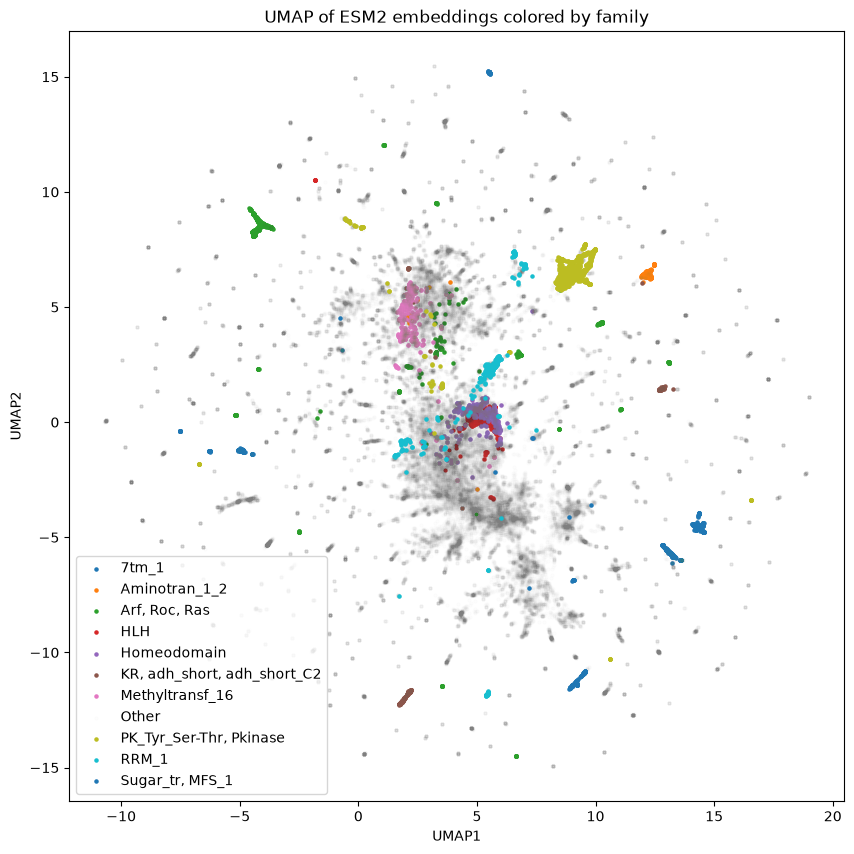

In [ ]:
# Static
fig, ax = plt.subplots(figsize=(10, 10))
for family, group in df.groupby('Common Families'):
    ax.scatter(
        group['UMAP1'], 
        group['UMAP2'], 
        label=family, 
        alpha=0.01 if family == 'Other' else 1.0, 
        s=5
    )
ax.legend()
plt.title('UMAP of ESM2 embeddings colored by family')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

In [ ]:
import px as 